# Reinforcement Learning for Robotic Task Recognition in Event-Driven Environments

This project will implement a **Reinforcement Learning (RL)** algorithm to enable a **robotic arm** to interact with the right box based on observable events. The objective is to develop an RL-based system in which a robot can recognize and respond to **complex, sequential decision-making scenarios** within a dynamic, event-driven environment. Specifically, the robot will control a robotic arm that reacts to these changing situations.

To achieve this, we will use **simulations like PyBullet** for robotic tasks and the **Open the Chests (OtC) environment** to tackle complex sequential decision-making challenges. The Open the Chests environment provides a **sequential event-based world** where the robot can observe and make informed decisions. Meanwhile, PyBullet will be used to **simulate the control of a robotic arm**, enabling it to physically respond to situations and manipulate objects.

The project combines two ideas:

1. **Robotic control in simulation** using **PyBullet** and a custom KUKA environment.
2. **Event-driven decision making** using the **Open the Chests** environment.

Your overall goal is to design a system that can:

- observe its environment,
- recognize useful patterns,
- decide which chest should be opened,
- and move the robotic arm to the correct target.

## Relevant Documentation and Libraries

To better understand and implement the project, the following resources and libraries are recommended:

### Reinforcement Learning Libraries:
- **Stable Baselines3**: RL framework with pre-implemented algorithms. [📖 Documentation](https://stable-baselines3.readthedocs.io/en/master/)
- **Gymnasium (formerly OpenAI Gym)**: Toolkit for developing RL environments. [📖 Documentation](https://gymnasium.farama.org/)
- **RL Baselines3 Zoo**: Collection of pre-trained RL agents. [📖 GitHub](https://github.com/DLR-RM/rl-baselines3-zoo)

### Robotic Simulation:
- **PyBullet**: Physics engine for robotic simulations. [📖 Documentation](https://pybullet.org/) [📖 Quicktart Guide](https://docs.google.com/document/d/10sXEhzFRSnvFcl3XxNGhnD4N2SedqwdAvK3dsihxVUA/edit?tab=t.0)


### Open the Chests (OtC) Environment:
- **OtC Environment Overview**: Sequential event-based RL scenario. [📖  GitHub ](https://github.com/ThalesGroup/open-the-chests) [📖 Article ](https://drops.dagstuhl.de/entities/document/10.4230/LIPIcs.TIME.2024.5) [📖 Presentation ](https://www.lirmm.fr/time2024/files/OpenTheChestsTIME2024.pdf)

## Project roadmap and expected outcomes

By the end of the project, your notebook or report should contain clear evidence for all three parts.

### Task 1: Robotic control in PyBullet
Build and test an RL agent that can move the KUKA arm toward the correct colored chest.

*Suggested analysis* : You should show that you can load the KUKA environment, explain the state/action/reward setup, and evaluate a controller. It's recommended to provide analysis and comparisons during training to highlight your understanding of the process. For example, provide multiple curves on different training setups you made and explain the difference between the two.

### Task 2: Event recognition in Open the Chests
Study how event sequences of increasing complexity determine which chest should be opened.

*Suggested analysis* : You should compare the easy, medium, and hard Open the Chests settings and explain which cases require memory or temporal reasoning. Explain in which settings the algorithm struggles and why. For example, provide a visualisation of the embeddings of a trained model and explain its capacity to cluster activities.

### Task 3: Combine the two environments
Connect event recognition to robotic control so that one component identifies the correct chest and another component executes the motion.

*Suggested analysis* : You should explain how the event-recognition module tells the robot-control module which chest to open, and you should include at least one evaluation result, visualization, or pipeline design. Currently the two systems are separated, suggest a possible combination and explain possible advantages/disadvantages.

## Files used in this project

This notebook assumes the provided file `colored_chest_kuka_env.py` and `register_envs.py` are available in the same working directory.

In [1]:
# Install the main libraries used across the full project.
# If you already have these packages, this cell is safe to skip.

!pip install -q gymnasium pybullet stable-baselines3 matplotlib imageio imageio-ffmpeg

print("Dependencies installed.")

Dependencies installed.


In [2]:
!pip install git+https://github.com/ThalesGroup/open-the-chests.git@0.7.5

  Cloning https://github.com/ThalesGroup/open-the-chests.git (to revision 0.7.5) to /tmp/pip-req-build-2618cgpr
  Running command git clone --filter=blob:none --quiet https://github.com/ThalesGroup/open-the-chests.git /tmp/pip-req-build-2618cgpr
  Running command git checkout -q a5f806d46fec72d960fd0b8de895927e0523e5b0
  Resolved https://github.com/ThalesGroup/open-the-chests.git to commit a5f806d46fec72d960fd0b8de895927e0523e5b0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. RL Environment with PyBullet

## Goal
The objective of this section is to **use a RL environment** using **PyBullet**, where a robotic arm learns to **reach for a specific chest** based on input commands. The robot must **autonomously decide and execute movements** to successfully complete the task.


## Suggested Approach

A reasonable workflow is:

- start with a **random-policy sanity check**,
- inspect the reward and success signal,
- train a baseline controller such as **PPO**,
- then evaluate whether the robot reaches the correct chest reliably,
- if needed, modify reward shaping or model parameters and make ablations to compare the difference

*Attention: You may modify the environment file if needed to test different reward functions.*

## Summary of the Environment

`ColoredChestKukaEnv` is a robotic manipulation reinforcement learning environment built around a **KUKA robotic arm** interacting with **colored chests** in a simulated scene. The agent learns to control the robot so it interacts with the correct chest based on the task configuration.

### Environment State (Observation)

Observations returned by the environment describe the current physical configuration of the robot and the objects. The observation vector typically includes values derived from variables such as:

- **End-effector position** (from the robot state, typically retrieved using the robot link state).
- **Chest positions**, stored internally in variables such as `self.chest_positions`.
- **Target color information**, usually stored in a variable like `self.target_color`.
- **Robot joint states or gripper state**, depending on the configuration.

These values are aggregated and returned by the `_get_obs()` method, which constructs the observation returned at each `step()`.

### Action Space

The agent acts through the environment's `action_space`, which controls the **movement of the robot end-effector**.

Typical actions include:
- $\delta x$, $\delta y$, $\delta z$ movements applied to the end-effector
- optional gripper control

Actions are processed in the `step(self, action)` method, where they are converted into robot motion commands applied to the KUKA arm in the simulation.

### Reward Computation

Rewards are computed inside the `step()` function using environment variables such as:

- `self.target_color`
- chest positions stored in `self.chest_positions`
- the robot end-effector position

The reward generally reflects:
- **distance between the end-effector and the correct chest**
- **successful interaction with the chest matching `self.target_color`**

This may involve distance calculations and success checks implemented in helper logic inside `step()`.

### Episode Termination

Episodes terminate when one of the following conditions occurs:

- **Task success**: the robot correctly interacts with the chest corresponding to `self.target_color`.
- **Maximum number of steps**: tracked internally (commonly via a counter such as `self.step_count` or similar).
- **Environment constraints violated** (depending on implementation).

Termination flags are returned by the `step()` method as `terminated` or `truncated`.

### Reset Behavior

The `reset()` method initializes a new episode by:

- resetting the simulation
- placing the robot back in its **initial pose**
- randomly or deterministically assigning chest positions (`self.chest_positions`)
- sampling the **target color** (`self.target_color`)

This ensures that each episode begins from a consistent starting state.

### Rendering

Rendering is supported through the environment’s `render()` method. When enabled, it visualizes:

- the **KUKA robotic arm**
- the **colored chests**
- the current manipulation attempt

Rendering is mainly used for debugging, demonstrations, or visualizing trained policies.

In [3]:
# Core Gymnasium API
import gymnasium as gym

# Import the module that contains ColoredChestKukaEnv.
# This is important because the `register(...)` call inside that file
# only runs when the module is imported.
import colored_chest_kuka_env

# Utilities for building an in-memory GIF so we can display it inline
# without writing a video or gif file to disk.
import io
import imageio

# IPython display tools for showing the animation directly in the notebook.
from IPython.display import Image, display

In [4]:
# Create the environment through Gymnasium's registry.
#
# Important arguments:
# - render_mode="rgb_array":
#   required when you want rendered frames as NumPy arrays, which is the
#   standard mode for notebook/Colab visualizations.
#
# - reward_type="advanced":
#   uses the environment's more detailed reward logic, assuming your env
#   supports this keyword argument.
#
# - max_steps=150:
#   sets the per-episode step budget if your environment constructor accepts it.
env = gym.make(
    "ColoredChestKuka-v0",
    render_mode="rgb_array",
    reward_type="advanced",
    max_steps=150,
)

# Reset the environment to obtain the initial observation and info dictionary.
obs, info = env.reset()

# Print a few useful details so you can quickly verify the environment loaded
# as expected and inspect its spaces.
print("Environment created successfully.")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Initial info:", info)

Environment created successfully.
Observation space: Box(-inf, inf, (10,), float32)
Action space: Box(-0.05, 0.05, (3,), float32)
Initial info: {'target_idx': 2, 'target_color_rgba': [0.0, 0.0, 1.0, 1.0]}


In [5]:
# This list will store the rendered frames returned by env.render().
# Each frame is usually a NumPy array of shape (H, W, 3).
frames = []

# Number of random actions to try.
# You can increase this if you want a longer animation.
num_steps = 80

# Reset once more so the rollout starts from a clean initial state.
obs, info = env.reset()

for step_idx in range(num_steps):
    # Render the current state BEFORE taking the action, so the first frame
    # shows the initial configuration of the scene.
    frame = env.render()
    frames.append(frame)

    # Sample a random valid action from the environment's action space.
    # This is useful for smoke-testing that stepping and rendering work.
    action = env.action_space.sample()

    # Apply the action to the environment.
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"obs={obs}, reward={reward}, terminated={terminated}, truncated={truncated}, info={info}")

    # Optional debug print for quick inspection during development.
    # print(
    #    f"step={step_idx:03d} | reward={reward:.3f} | "
    #    f"terminated={terminated} | truncated={truncated}"
    #)

    # Stop the rollout cleanly if the episode has ended.
    if terminated or truncated:
        # Capture one final frame after the terminal transition so the
        # animation includes the end state.
        frames.append(env.render())
        print("Episode finished early.")
        break

obs=[ 0.9478737  -0.20099369  1.2767248   0.88063943  0.16743165  0.73
  0.          0.          1.          0.00666667], reward=-0.6626957654953003, terminated=False, truncated=False, info={'is_success': False, 'distance_to_target': 0.6626957654953003, 'target_idx': 2, 'target_color_rgba': [0.0, 0.0, 1.0, 1.0], 'consecutive_close_steps': 0}
obs=[ 0.94924974 -0.20185633  1.2701877   0.88063943  0.16743165  0.73
  0.          0.          1.          0.01333333], reward=-0.6579390168190002, terminated=False, truncated=False, info={'is_success': False, 'distance_to_target': 0.6579390168190002, 'target_idx': 2, 'target_color_rgba': [0.0, 0.0, 1.0, 1.0], 'consecutive_close_steps': 0}
obs=[ 0.9507645  -0.20577294  1.2639956   0.88063943  0.16743165  0.73
  0.          0.          1.          0.02      ], reward=-0.6552484631538391, terminated=False, truncated=False, info={'is_success': False, 'distance_to_target': 0.6552484631538391, 'target_idx': 2, 'target_color_rgba': [0.0, 0.0, 1.0, 1.0]

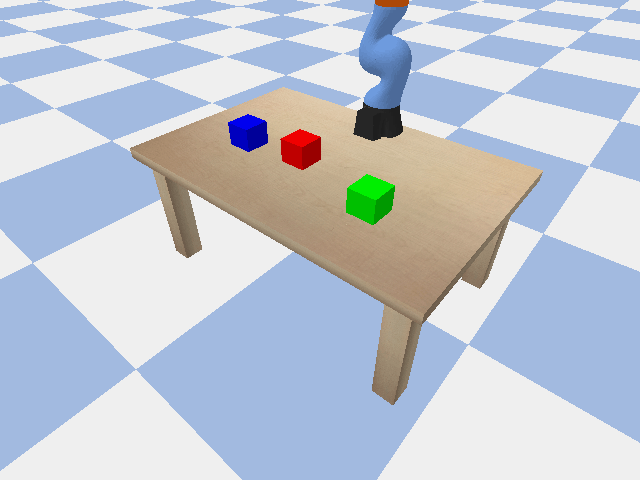

In [6]:
# Build a GIF fully in memory using BytesIO.
# This avoids saving any file such as "kuka_demo.gif" to disk.
gif_buffer = io.BytesIO()

# `imageio.mimsave` writes the animated GIF into the in-memory buffer.
# `format="GIF"` is specified explicitly for clarity.
#
# `fps=12` controls playback speed:
# - lower value -> slower animation
# - higher value -> faster animation
imageio.mimsave(gif_buffer, frames, format="GIF", fps=12)

# Rewind the buffer to the beginning before reading its bytes.
gif_buffer.seek(0)

# Display the GIF directly in the notebook output.
display(Image(data=gif_buffer.getvalue()))

In [7]:
# This cell reuses the `frames` list collected earlier and writes an MP4
# in a Colab-friendly way, then embeds it directly in the notebook output.

import imageio
import numpy as np
from IPython.display import Video

video_path = "kuka_episode.mp4"

# Ensure every frame is a NumPy array with uint8 dtype, which video encoders expect.
frames_np = [np.asarray(f, dtype=np.uint8) for f in frames]

# Write the MP4 video.
# macro_block_size=None avoids automatic resizing warnings/errors for odd frame sizes.
imageio.mimsave(
    video_path,
    frames_np,
    fps=20,
    codec="libx264",
    macro_block_size=None,
)

print("Video generated:", video_path)

# In Colab, embed=True is usually necessary for the video to display correctly.
Video(video_path, embed=True)#

Video generated: kuka_episode.mp4


In [8]:
# Always close the environment when finished.
# This is especially important for simulation-based environments.
env.close()
print("Environment closed.")

Environment closed.


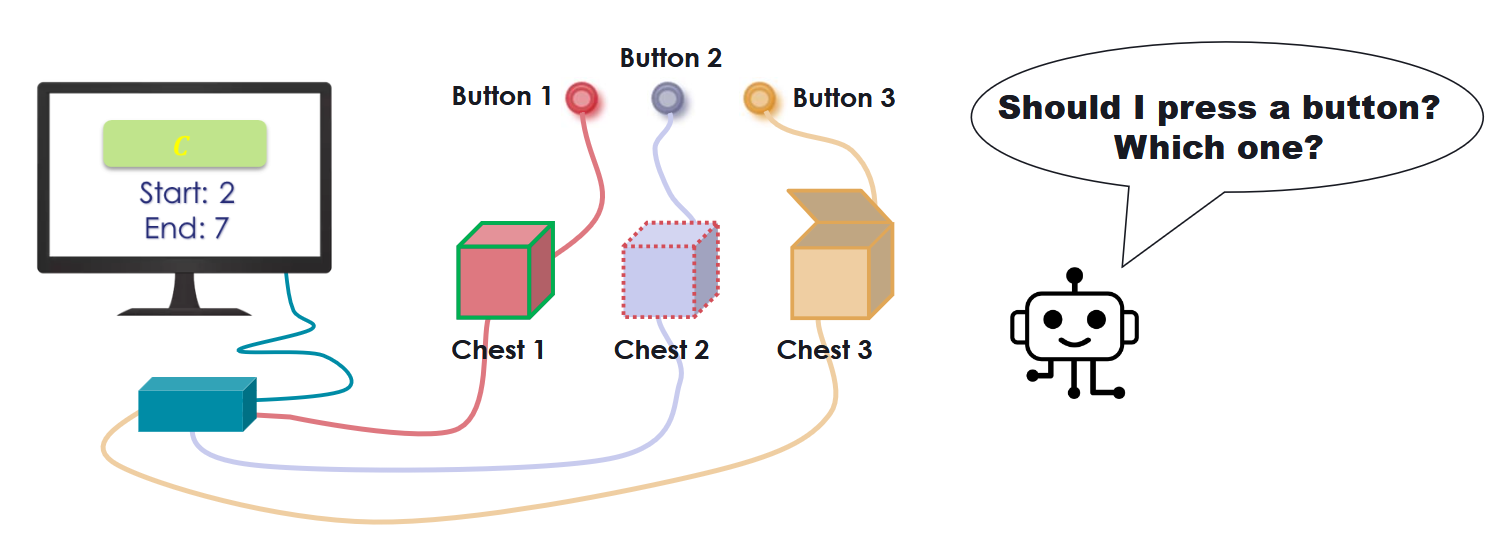


## 1. "Open the Chests" Environment

The **Open the Chests** environment introduces **event-driven decision-making**, where the agent must **recognize patterns in an event stream** and take the appropriate action. The environment simulates a scenario where **various activities generate a stream of events**, each representing a **significant observation**.

The agent's goal is to:
- **Recognize event signatures** in the stream.
- **Associate events with specific activities**.
- **Use this information to open the correct chest** by taking the appropriate action (e.g., pressing a button).

This requires the agent to **learn how to interpret event sequences** and **respond accordingly**.

### Goal

The key difficulty in this environment is handling **asynchronous and sequential events**. The agnt must:
- **Interpret real-time event streams** where new information continuously arrives.
- **Recognize patterns** in events occurring at different points in time.
- **Distinguish relevant events** from noise in the event stream.
- **Identify and execute the correct action** based on learned patterns.

As event sequences become more **complex and interdependent**, the learning problem shifts from a simple **one-to-one mapping** to a **time-dependent decision-making** challenge.

## Summary of the Environment

`Open the Chests` is a **reinforcement learning environment focused on temporal event reasoning**. The agent interacts with **several chests through their corresponding buttons**, while observing a stream of **symbolic events**. The goal is to discover the hidden rule that determines **when pressing a button will successfully open a chest**.

Unlike robotics environments (e.g., KUKA manipulation), this environment focuses on **logical and temporal reasoning over discrete events** rather than physical control.


### Core Idea

The agent must reason about the relationship between:
- the **observed event stream**
- the **buttons / chests available for interaction**
- the hidden temporal rules that determine whether pressing a button opens a chest or has no effect.

This makes the environment useful for studying:
- **event-pattern recognition**
- **activity / situation recognition**
- **temporal reasoning**
- **reinforcement learning with structured rules**.


## Observations

At each timestep the agent observes information about the **most recently completed event** and the **current state of the chests**.

The observation contains two main components:

### 1. Last Completed Event

The environment provides a description of the **last event that occurred**.  
This event is represented by:

- **A letter** identifying the event type (e.g. `A`, `B`, `C`, ...).
- **Additional attributes** describing the event:
  - **Foreground color**
  - **Background color**

These attributes together define the event's identity and context.

### 2. Chest State

The agent also observes which chests have already been opened.

This information is provided as a **binary vector**: $opened\_chests \in \{0,1\}^K$ where:

- `K` is the number of chests.
- `0` means the chest is still closed.
- `1` means the chest has already been opened.

This allows the agent to know **which actions remain meaningful**.


## Action Space

The action space is **discrete**. Each action corresponds to **attempting to open one chest**.

If there are `K` chests, the action space is: $action \in \{0, 1, ..., K-1\}$

Selecting an action means the agent **presses the button corresponding to that chest**.


## Reward Signal

Rewards depend on whether the agent **opens a chest at the correct time**, according to the hidden rule governing the environment.

Typical outcomes include:

- **Positive reward** when a chest is opened under the correct event conditions.
- **Negative reward** when the agent attempts to open a chest at the wrong time.

Because the rules depend on the **sequence and properties of events**, the agent must learn to **interpret event attributes and temporal structure**.


## Observable vs Hidden Information

The agent can observe:

- The **last completed event**
- The **binary vector of opened chests**

The agent cannot observe:

- The **rule or pattern** determining when a chest should be opened.
- The **event history beyond the most recent event**.
- Any internal environment state used to evaluate success.

The agent must therefore **infer the correct opening conditions from experience**.


## Episode Dynamics

An episode proceeds as follows:

1. The environment generates an event.
2. The agent observes the **last completed event** and **which chests are already open**.
3. The agent chooses a chest to attempt to open.
4. The environment returns a reward depending on whether the hidden rule is satisfied.
5. The process repeats with a new event.

Episodes terminate when:

- All chests are opened, or
- A maximum number of steps is reached.


## Difficulty levels used in this notebook

The notebook defines three levels of increasing complexity, each defining 3 chests with varying difficuly of their associated activities. The three difficulty levels represent increasing temporal complexity:

- **Easy (`OpenTheChests-v0`)**: a chest is identified by a short and simple event pattern.
- **Medium (`OpenTheChests-v1`)**: the agent must recognize longer dependencies.
- **Hard (`OpenTheChests-v2`)**: the agent must handle long and noisy temporal structure.

As difficulty increases, the need for memory and temporal reasoning also increases.



## Suggested Approach

The **solution** to this problem can be approached at **multiple levels of complexity**:

### 1. Simple Approach: Temporal Windows
- Implement a **time window** where the agent **stores and analyzes recent events**.
- The agent can **recognize simple event sequences** by considering a **short history**.

### 2. Advanced Approach: Transformers or Reccurence for Temporal Dependencies
- **Utilize deep learning techniques** such as:
  - **Recurrent Neural Networks (RNNs)**
  - **Long Short-Term Memory (LSTMs)**
  - **Transformers (e.g., GPT or BERT-like models)**
- These models allow the agent to:
  - **Process complex event sequences** spanning many steps.
  - **Learn temporal relationships** and **predict upcoming events**.
  - **Generalize across different event patterns** instead of memorizing specific cases.





Step 1: Action=0, Reward=0, Done=False
Step 2: Action=0, Reward=0, Done=False
Step 3: Action=0, Reward=-1, Done=False
Step 4: Action=0, Reward=0, Done=False
Step 5: Action=0, Reward=0, Done=False
Step 6: Action=0, Reward=-1, Done=False
Step 7: Action=0, Reward=0, Done=False
Step 8: Action=0, Reward=0, Done=False
Step 9: Action=0, Reward=-1, Done=False
Step 10: Action=0, Reward=0, Done=False


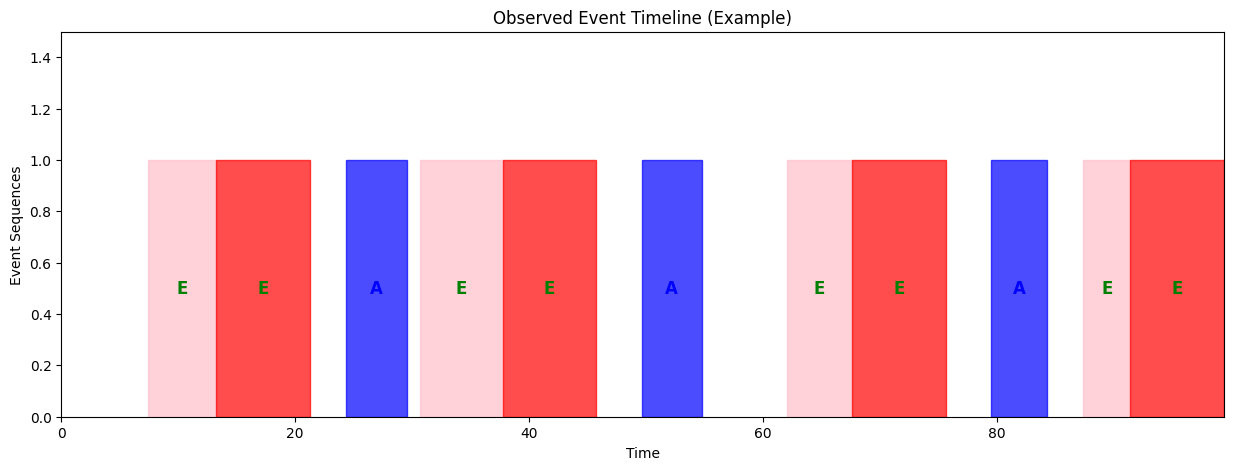

In [9]:
# ------------------------------------------------------------------------------
# OpenTheChestsGym Environment Interaction & Event Visualization
# ------------------------------------------------------------------------------
# This script demonstrates:
# - How to initialize and interact with the OpenTheChestsGym environment.
# - How to extract event data from the environment.
# - How to visualize observed events in a timeline.
#
# The script follows these steps:
# 1. Define event types, attributes, and instructions.
# 2. Initialize the environment with the given configuration.
# 3. Run a loop to collect events while interacting with the environment.
# 4. Visualize the collected events using a timeline plot.
# ------------------------------------------------------------------------------

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import gymnasium as gym
from openthechests.src.OpenTheChestsGym import OpenTheChestsGym

# --------------------------------------------------------
# INITIALIZE THE ENVIRONMENT
# --------------------------------------------------------

# Define the list of event types and their attributes
all_event_types = ['A', 'B', 'C', 'D', 'E']
all_event_attributes = {
    'fg': ['red', 'blue', 'green', 'orange', 'pink'],
    'bg': ['red', 'blue', 'green', 'orange', 'pink']
}

# Define noise event types and attributes
all_noise_types = ['G', 'H', 'F']
all_noise_attributes = {
    'fg': ['yellow', 'purple', 'black'],
    'bg': ['yellow', 'purple', 'black']
}

# Define event instructions (simulating sequences of actions and dependencies)
instructions = [
    [
        {'command': 'delay', 'parameters': 10},
        {'command': 'instantiate', 'parameters': ('A', {'bg': 'blue', 'fg': 'blue'}, {'mu': 5, 'sigma': 2}), 'variable_name': 'distinct'},
        {'command': 'instantiate', 'parameters': ('E', {'bg': 'pink', 'fg': 'green'}, {'mu': 6, 'sigma': 2}), 'variable_name': 'e1'},
        {'command': 'instantiate', 'parameters': ('E', {'bg': 'red', 'fg': 'green'}, {'mu': 8, 'sigma': 0}), 'variable_name': 'e2'},
        {'command': 'met_by', 'parameters': ['e2', 'e1'], 'variable_name': 'e2', 'other': {}},
        {'command': 'after', 'parameters': ['distinct', 'e2'], 'variable_name': 'distinct', 'other': {'gap_dist': {'mu': 4, 'sigma': 1}}}
    ]
]

# Initialize the OpenTheChestsGym environment
env = OpenTheChestsGym(instructions=instructions,
                       all_event_types=all_event_types,
                       all_event_attributes=all_event_attributes,
                       all_noise_types=all_noise_types,
                       all_noise_attributes=all_noise_attributes,
                       verbose=False,
                       discrete=True, # If True actions are discrete, meaning that an action corresponds to the number of the box to open.
                                       # If False actions are binary vectors, meaning that a 0 at index i corresponds to pushing the buton i.
                       stb3=False)

# --------------------------------------------------------
# COLLECT EVENT OBSERVATIONS
# --------------------------------------------------------

def event_from_obs(obs):
    """
    Extracts event information from the environment observation.
    Converts indices into human-readable symbols and colors.
    """
    event = obs["context"]
    return {
        "symbol": all_event_types[event.type],  # Convert event index to actual event type
        "bg_color": all_event_attributes["bg"][event.attributes["bg"]],  # Convert bg index to color
        "symbol_color": all_event_attributes["fg"][event.attributes["fg"]],  # Convert fg index to color
        "start_time": event.start,
        "end_time": event.end
    }

# Store observed events
observed_events = []

# Reset environment and initialize observation
obs, _ = env.reset()
observed_events.append(event_from_obs(obs))

# Run simulation loop to collect events
for step in range(10):
    action = 0  # Fixed action (Can be randomized using env.action_space.sample())
    obs, reward, done, truncated, info = env.step(action)  # Take a step in the environment
    done = done or truncated

    # Extract event from `obs["context"]`
    if "context" in obs and obs["context"] is not None:
        observed_events.append(event_from_obs(obs))

    print(f"Step {step+1}: Action={action}, Reward={reward}, Done={done}")

    if done:
        print("Environment reached a terminal state. Resetting...")
        obs = env.reset()

# --------------------------------------------------------
# VISUALIZE EVENT SEQUENCES
# --------------------------------------------------------

def draw_event_sequence_matplot(events, start_time=0, end_time=50, env_name = "Example"):
    """
    Visualizes the observed event sequence as a timeline, showing event occurrences over time.
    """
    # Create the figure and axis with a larger width
    fig, ax = plt.subplots(figsize=(15, 5))  # Increased width from 10 to 15

    last_event_end_times = []  # Track end times to avoid overlapping
    height = 1  # Height of each event bar

    for event in events:
        event_name = event["symbol"]
        start = event["start_time"]
        end = event["end_time"]
        color = event["bg_color"]
        text_color = event["symbol_color"]

        # Find the correct row for the event (avoid overlapping)
        line = 0
        while line < len(last_event_end_times):
            if start >= last_event_end_times[line]:  # If space is available in this line
                break
            line += 1
        if line == len(last_event_end_times):
            last_event_end_times.append(end)
        else:
            last_event_end_times[line] = end

        # Draw the event as a rectangle
        y_pos = line * (height + 0.5)
        rect = patches.Rectangle((start, y_pos), max(end - start, 0.1), height, color=color, alpha=0.7)  # Ensure non-zero width
        ax.add_patch(rect)

        # Label the event in the center of the rectangle
        ax.text(start + (end - start) / 2, y_pos + height / 2, event_name,
                horizontalalignment='center', verticalalignment='center',
                color=text_color, fontsize=12, fontweight='bold')

    # Set limits and labels
    ax.set_xlim(start_time, end_time)
    ax.set_ylim(0, len(last_event_end_times) * (height + 0.5))
    ax.set_xlabel("Time")
    ax.set_ylabel("Event Sequences")
    ax.set_title("Observed Event Timeline " + f'({env_name})')
    plt.show()


# Call the function to plot the observed event sequence
draw_event_sequence_matplot(observed_events, start_time=0, end_time=observed_events[-1]["end_time"])

# Close the environment
env.close()

### **Configurations**
The complexity of the problem can be adjusted based on how events are structured and how much information the robot must process. Below are the **four defined environments** with increasing levels of difficulty.

#### **1. Easy: 3 Chests, 1 Event Per Chest** (`OpenTheChests-v0`)
- Each **chest is associated with a single event**.
- The robot **only needs to react to a single event** to identify the correct chest.
- **No historical context or sequence tracking** is required.
- **Challenge Level: Minimal** – A simple one-to-one mapping between an event and an action.
- Example:
  - **Event A** → Open **Chest 1**  
  - **Event B** → Open **Chest 2**  
  - **Event C** → Open **Chest 3**  

#### **2. Medium: 3 Chests, 4 Events Per Chest** (`OpenTheChests-v1`)
- Each chest is associated with **a sequence of 4 events**.
- The robot **must recognize short event sequences** to determine the correct chest.
- **Some memory and sequence tracking** are required.
- **Challenge Level: Moderate** – The robot must understand simple temporal dependencies.
- Example:
  - **Event A → Event B → Event C → Event D** → Open **Chest 1**  
  - **Event X → Event Y → Event Z → Event W** → Open **Chest 2**  
  - **Event M → Event N → Event O → Event P** → Open **Chest 3**  

#### **3. Hard: 3 Chests, 16 Events Per Chest** (`OpenTheChests-v2`)
- Each chest is associated with a **complex sequence of 16 events**.
- The robot **must track long-term dependencies** between events.
- **Deep memory and advanced pattern recognition** are necessary.
- **Challenge Level: High** – The robot must handle **complex sequential dependencies** and **avoid distractions**.
- Example:
  - **Event red A → after blue B → during C → after D → ... → Event P** → Open **Chest 1**  
  - **Event X → during red Y → after pink Z → during W → ... → Event O** → Open **Chest 2**  
  - **Event M → met_by N → during O → after P → ... → Event R** → Open **Chest 3**  

### **Testing Different Complexity Levels**
These three configurations allow testing the **robot’s ability to recognize patterns** in **low, medium, and high complexity cases**.

- **In the Easy environment**, the agent can use **basic reinforcement learning** to associate a **single event** with the correct action.
- **In the Medium environment**, the agent can use **simple memory storage** to correctly identify **event patterns**.
- **In the Hard environment**, the agent requires **advanced memory mechanisms (LSTMs, Transformers, or Attention-based models)** to detect **long event sequences**.

This setup allows for a **progressive increase in difficulty**, helping to evaluate **how different agents perform at various levels of complexity**.


In [12]:
from register_envs import all_types, all_attributes, register_custom_envs

def event_from_obs_stb3(obs, types, attributes):
    """
    Extracts event information from the environment observation.
    Converts indices into human-readable symbols and colors.
    """
    return {
        "symbol": types[obs["e_type"]],  # Convert event index to actual event type
        "bg_color": attributes["bg"][obs["bg"]],  # Convert bg index to color
        "symbol_color": attributes["fg"][obs["fg"]],  # Convert fg index to color
        "start_time": obs["start"][0],
        "end_time": obs["end"][0]
    }

register_custom_envs()

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment OpenTheChests-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment OpenTheChests-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment OpenTheChests-v2 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment OpenTheChests-v0 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: U

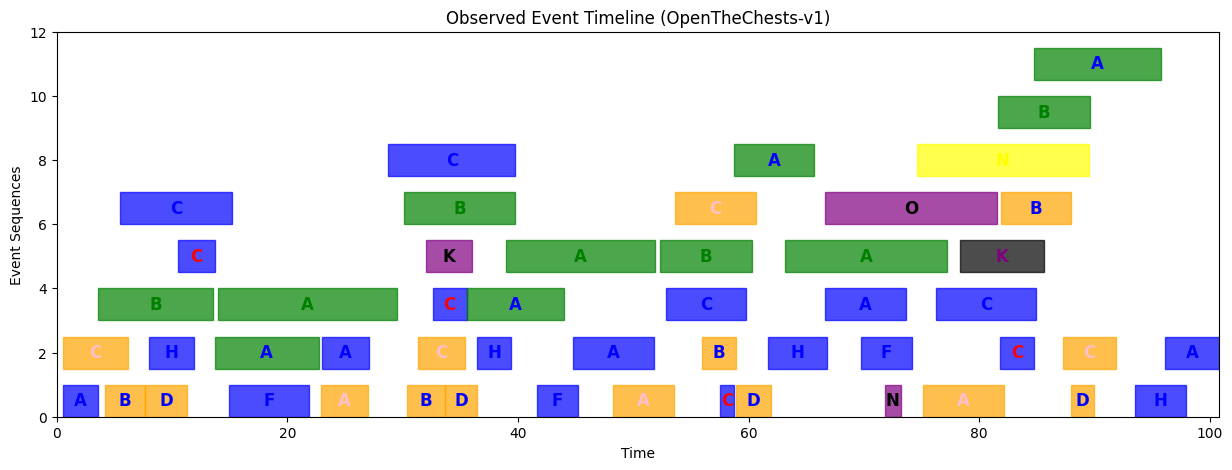

In [13]:
# --------------------------------------------------------
# COLLECT OBSERVATIONS FROM BOTH ENVIRONMENTS
# --------------------------------------------------------

def collect_observations(env_name, num_steps=30):
    """
    Collects event observations from a given OpenTheChests environment.

    Args:
        env_name (str): The registered environment name ("OpenTheChests-v0" or "OpenTheChests-v1").
        num_steps (int): Number of observations to collect.

    Returns:
        list: Collected event observations.
    """

    # Create the environment
    env = gym.make(env_name)

    # Store observed events
    observed_events = []

    # Reset environment and initialize observation
    obs, _ = env.reset()
    observed_events.append(event_from_obs_stb3(obs, all_types, all_attributes))

    # Run simulation loop to collect events
    for step in range(num_steps):
        action = [0] * env.action_space.n  # Fixed action (Can be randomized using env.action_space.sample())
        obs, reward, done, _, info = env.step(action)  # Take a step in the environment

        # Extract event information
        observed_events.append(event_from_obs_stb3(obs, all_types, all_attributes))

        # print(f"Step {step+1} ({env_name}): Action={action}, Reward={reward}, Done={done}")

        if done:
            print(f"{env_name} reached a terminal state. Resetting...")
            obs = env.reset()

    # Close the environment
    env.close()

    return observed_events

# Collect data from both environments
observed_events_easy = collect_observations("OpenTheChests-v0", num_steps=10)
observed_events_medium = collect_observations("OpenTheChests-v1", num_steps=50)
observed_events_hard = collect_observations("OpenTheChests-v2", num_steps=100)

# --------------------------------------------------------
# VISUALIZE EVENT SEQUENCES
# --------------------------------------------------------

# Visualize collected observations sequentially
#draw_event_sequence_matplot(observed_events_easy, start_time=0, end_time=observed_events_easy[-1]["end_time"], env_name="OpenTheChests-v0")
draw_event_sequence_matplot(observed_events_medium, start_time=0, end_time=observed_events_medium[-1]["end_time"], env_name="OpenTheChests-v1")
#draw_event_sequence_matplot(observed_events_hard, start_time=0, end_time=observed_events_hard[-1]["end_time"], env_name="OpenTheChests-v2")


## 3. Combining the Two Environments

## Objective
The goal of this step is to **integrate robotic control** with the **Open the Chests** environment, creating a **dual-agent system** where one agent focuses on **event recognition**, and the other handles **robotic movement and task execution**.

### Two-Agent System
The system consists of **two specialized agents** that work together to achieve the objective:

#### Agent 1: Event Recognition Agent
- **Role:** Identifies when it is time to open a chest based on the observed event stream.
- **Task:** Recognizes **patterns in event sequences** and determines the correct **moment for action**.
- **Challenge:** Must handle **asynchronous event streams** and recognize **sequential dependencies**.

#### Agent 2: Robotic Control Agent
- **Role:** Controls the **robotic arm**, moving it to the correct chest and performing the action of opening it.
- **Task:** Receives signals from **Agent 1**, executes movement, and performs the physical **interaction with the chest**.
- **Challenge:** Accurately **execute motor control** and properly **coordinate** with **Agent 1**.

### Goal
The **dual-agent system** must function **cooperatively**, where:
- **Agent 1 / Event-recognition module:** watches the event stream and decides which chest should be opened.
- **Agent 2 / Robotic-control module:** receives the target chest identity and moves the robot arm to the correct location.

### Suggested Approach
To effectively **solve this problem**, the following **strategy** is recommended:

1. Event Recognition (Agent 1)
   - **Process the event stream** using a suitable pattern recognition method.
   - Possible techniques include:
     - **Temporal Windows** – Track events over a time window to detect relevant sequences.
     - **Transformers / LSTMs** – Use deep learning models to analyze complex event dependencies.
   - Once a **chest-opening pattern** is detected, **send a signal** to Agent 2.

2. Robotic Control (Agent 2)
   - **Receive the signal** from Agent 1.
   - Move the **robotic arm** to the identified chest.
   - Perform the **physical interaction**.
   - Confirm the **completion of the task** to the Open the Chests (OtC) environment.

3. Cycle Reset & Continuation
   - After the chest is opened:
     - **Agent 1 resumes event observation** to detect the next relevant sequence.
     - The **robot arm may reset** to an initial position before processing the next task.
   - The cycle repeats, allowing for **continuous operation**.


In [21]:
import gymnasium as gym
import numpy as np

# -----------------------------------------------------------
# Very simplified mock loop showing how the two environments
# interact.
# -----------------------------------------------------------

# Create the two environments
otc_env = gym.make("OpenTheChests-v0")
physical_env = gym.make("ColoredChestKuka-v0")

# Simple mock model: just sample random actions
class MockModel:
    def __init__(self, action_space):
        self.action_space = action_space

    def predict(self, obs, state=None, deterministic=True):
        action = self.action_space.sample()
        return action, state

# One mock model for each environment
modelOTC = MockModel(otc_env.action_space)
modelKUKA = MockModel(physical_env.action_space)

# Reset OTC environment
obs_otc, _ = otc_env.reset()
done = False
state_otc = None

while not done:

    # =======================================================
    # 1. EVENT RECOGNITION (Agent 1 - OpenTheChests env)
    # =======================================================
    action_otc, state_otc = modelOTC.predict(
        obs_otc,
        state=state_otc,
        deterministic=True
    )

    # Find which chest(s) the mock agent wants to open
    chests_to_open = np.where(action_otc)[0]

    if len(chests_to_open) == 0:
        # No chest requested -> keep observing events
        obs_otc, reward_otc, done, truncated, info_otc = otc_env.step(action_otc)
        continue

    # =======================================================
    # 2. ROBOTIC CONTROL (Agent 2 - Physical KUKA env)
    # =======================================================
    for chest_id in chests_to_open:
        print(f"Agent 1 requests opening chest {chest_id}")

        # Reset physical environment
        obs_kuka, info_kuka = physical_env.reset()

        # Tell the robot which chest to interact with
        physical_env.target_idx = chest_id

        done_kuka = False
        truncated_kuka = False

        # Robot tries to perform the action
        while not done_kuka and not truncated_kuka:
            action_kuka, _ = modelKUKA.predict(obs_kuka, deterministic=True)
            obs_kuka, reward_kuka, done_kuka, truncated_kuka, info_kuka = physical_env.step(action_kuka)

        # Robot reports success / failure
        if info_kuka["is_success"]:
            print(f"Chest {chest_id} opened successfully")
        else:
            print(f"Chest {chest_id} failed to open")

    # =======================================================
    # 3. CYCLE CONTINUES
    # =======================================================
    # Inform the OTC environment about the action
    obs_otc, reward_otc, done, truncated, info_otc = otc_env.step(action_otc)

    # The process repeats:
    # Agent 1 keeps observing events
    # Agent 2 acts when a chest needs to be opened

physical_env.close()
otc_env.close()

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment OpenTheChests-v0 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: U

Agent 1 requests opening chest 0
Chest 0 failed to open
Agent 1 requests opening chest 2
Chest 2 failed to open
Agent 1 requests opening chest 0
Chest 0 failed to open
Agent 1 requests opening chest 1
Chest 1 failed to open
Agent 1 requests opening chest 2
Chest 2 failed to open
Agent 1 requests opening chest 1
Chest 1 failed to open
Agent 1 requests opening chest 2
Chest 2 failed to open
Agent 1 requests opening chest 0
Chest 0 failed to open
Agent 1 requests opening chest 0
Chest 0 failed to open
Agent 1 requests opening chest 1
Chest 1 failed to open
Agent 1 requests opening chest 2
Chest 2 failed to open
Agent 1 requests opening chest 2
Chest 2 failed to open
Agent 1 requests opening chest 1
Chest 1 failed to open
Agent 1 requests opening chest 2
Chest 2 failed to open



# Project Submission Guidelines

Your submission should include **three main components**: the project code, a notebook demonstrating results, and the trained model weights.

---

## 1. Project Code (ZIP Archive)

Submit a **`.zip` file** containing the full project code.

The archive must include:

- **All source code** necessary to run the project.
- A **`requirements.txt`** file listing all required Python packages so the project can be installed and reproduced easily.
- A **`README.md`** file explaining the **project structure** and how to run the code.


## 2. Results & Analysis Notebook

Submit a **Jupyter Notebook** demonstrating the trained system.

The notebook should:

- **Use the project's modules**  
  (e.g., import the environment and agent implementations).

- **Load and use the trained model weights** to demonstrate the agent’s performance.

- Include **high-level explanations** describing the approach.

- Include **visualizations**, such as:
  - Training reward curves
  - Performance metrics
  - Robot interaction examples
  - Event sequences or environment behavior

- Provide **analysis and commentary** explaining the results.

**Training curves and analysis are essential.**  
The notebook should clearly show how the agent improved during training and explain what the results mean.

## 3. Trained Model Weights

Submit the **saved trained model weights** used in your experiments.

Accepted formats include for example:

* `.zip`
* `.pth`
* `.h5`

The notebook **must load these weights** to reproduce the demonstrated results.

---

## Analysis Expectations

Your notebook (or an optional short report) should clearly explain:

* **What approaches you tried and why**
* **What worked well**
* **What challenges you encountered**
* **What you would improve with more time**

Good analysis is an important part of the project.
The goal is not only to obtain results, but also to **demonstrate understanding of the methods and their limitations**.